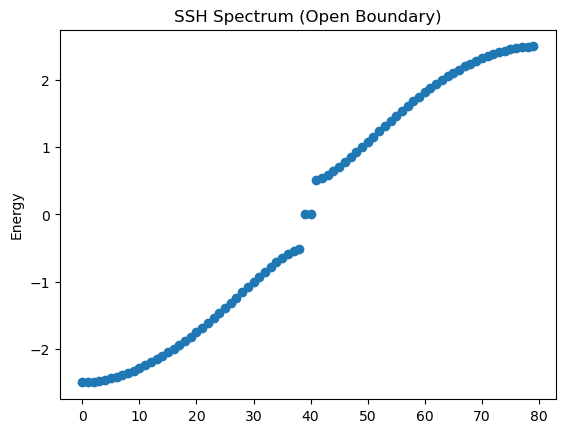

c:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29366 (\N{CJK UNIFIED IDEOGRAPH-72B6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24577 (\N{CJK UNIFIED IDEOGRAPH-6001}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


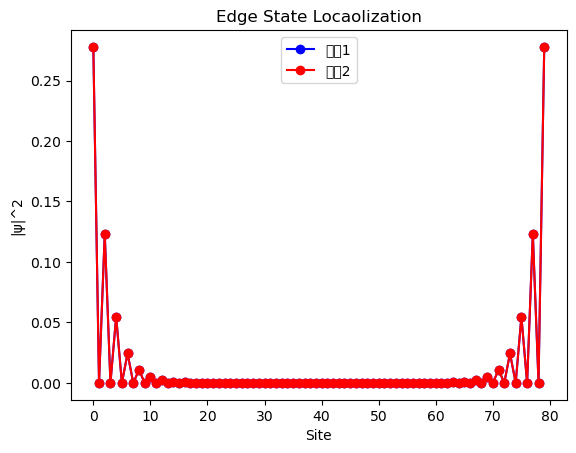

In [8]:
# %matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

#参数
N = 40      #单元数
t1 = 1.0
t2 = 1.5

#构造哈密顿量(open boundary)
H = np.zeros((2*N,2*N))

for i in range(N):
    # intracell hopping
    H[2*i,2*i+1] = t1
    H[2*i+1,2*i] = t1

    # intercell hopping
    if i < N-1:
        H[2*i+1,2*(i+1)] = t2
        H[2*(i+1),2*i+1] = t2

# 对角化
E,V = np.linalg.eigh(H)


# 画能谱
plt.plot(E,"o")
plt.ylabel("Energy")
plt.title("SSH Spectrum (Open Boundary)")
plt.show()


# 找最接近0的态
idx = np.argsort(np.abs(E)) #argsort:排序但只保存原来下标

psi1 = V[:,idx[0]]
psi2 = V[:,idx[1]]
#画概率分布
plt.plot(np.abs(psi1)**2,"-o",label = '状态1',color = 'b')
plt.plot(np.abs(psi2)**2,"-o",label = '状态2',color = 'r')
plt.legend()
plt.xlabel("Site")
plt.ylabel("|ψ|^2")
plt.title("Edge State Locaolization")
plt.show()

